# RNA-seq of DCM-TM iPSCs

This notebook performes a differential expression (DE) analysis on RNA-seq data of iPSCs with and without doxycycline to identify transcriptional changes.

## Input

- Raw RNA-seq gene counts, available from GEO (GSE304232_iPSCs.RNA-seq.raw.txt)

## Output 

- Figure S1d: MA plot showing DEGs between -dox and +dox
- Figure S1e: KEGG pathway enrichment of DEGs

## Packages

In [1]:
# General
from pathlib import Path
import numpy as np
import pandas as pd

# Plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Statistics
import scipy

# GO
import gseapy as gp

# Rpy2
%load_ext rpy2.ipython

# Plot settings
plt.rcParams.update({"figure.figsize": (10, 10), "svg.fonttype": "none", "font.family": "Arial"})
sns.set_style("ticks")

In [2]:
# Directories: update these paths as needed
input_dir = "../Input/GEO"   # folder where GEO data is stored
output_dir = "../Output"    # folder where output files will be saved
Path(output_dir).mkdir(parents=True, exist_ok=True)

# Settings
labels = ["iPSC", "DE", "PGT"]              # custom labels
colors = ["#264653", "#E9C46A", "#E76F51"]  # colors to use
palette = dict(zip(labels, colors))         # palette for plots

## DESeq2

In [3]:
%%R

# Load packages
packages <- c("DESeq2", "BiocParallel")
suppressMessages(invisible(lapply(packages, library, character.only = TRUE)))

# Set number of cores and memory to use
register(MulticoreParam(4))
options(future.globals.maxSize = 60000 * 1024^2, future.seed=42)
set.seed(42)

# List loaded packages
sessionInfo()

R version 4.4.0 (2024-04-24)
Platform: x86_64-conda-linux-gnu
Running under: Linux Mint 21.3

Matrix products: default
BLAS/LAPACK: /home/beatrice/miniconda3/envs/hDCM-TM/lib/libopenblasp-r0.3.25.so;  LAPACK version 3.11.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=nl_NL.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=nl_NL.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=nl_NL.UTF-8 LC_IDENTIFICATION=C       

time zone: Europe/Amsterdam
tzcode source: system (glibc)

attached base packages:
[1] stats4    tools     stats     graphics  grDevices utils     datasets 
[8] methods   base     

other attached packages:
 [1] BiocParallel_1.40.0         DESeq2_1.46.0              
 [3] SummarizedExperiment_1.36.0 Biobase_2.66.0             
 [5] MatrixGenerics_1.18.0       matrixStats_1.5.0          
 [7] GenomicRanges_1.58

In addition: There were 11 warnings (use warnings() to see them)


In [4]:
%%R -i input_dir

# Meta
sampleInfo <- data.frame(
  sampleName = c("iPSCs.dox.1", "iPSCs.dox.2", "iPSCs.dox.3", "iPSCs.nodox.1", "iPSCs.nodox.2", "iPSCs.nodox.3"),
  Dox        = c("dox", "dox", "dox", "nodox", "nodox", "nodox")
)

# Read raw RNA counts
counts_file <- paste(input_dir, "GSE304232_iPSCs.RNA-seq.raw.txt", sep="/")
counts <- read.table(counts_file, sep="\t", header=TRUE, row.names=1, check.names=FALSE)
counts <- counts[, sampleInfo$sampleName]

# Create DESeq2 dataset
dds <- DESeqDataSetFromMatrix(countData = counts, colData = sampleInfo, design = ~Dox)
dds

class: DESeqDataSet 
dim: 62703 6 
metadata(1): version
assays(1): counts
rownames(62703): ENSG00000160072 ENSG00000279928 ... ENSG00000277475
  ENSG00000275405
rowData names(0):
colnames(6): iPSCs.dox.1 iPSCs.dox.2 ... iPSCs.nodox.2 iPSCs.nodox.3
colData names(2): sampleName Dox


In addition: Warning message:
In DESeqDataSet(se, design = design, ignoreRank) :
  some variables in design formula are characters, converting to factors


In [5]:
%%R -o res_diff

dds <- DESeq(dds, fitType="parametric", parallel=TRUE, betaPrior=FALSE)

res_diff <- results(dds, contrast=c("Dox", "dox", "nodox"), alpha=0.05)
res_diff <- lfcShrink(dds, contrast=c("Dox", "dox", "nodox"), res=res_diff, type="ashr")

res_diff <- as.data.frame(res_diff)

estimating size factors
estimating dispersions
gene-wise dispersion estimates: 4 workers
mean-dispersion relationship
final dispersion estimates, fitting model and testing: 4 workers
using 'ashr' for LFC shrinkage. If used in published research, please cite:
    Stephens, M. (2016) False discovery rates: a new deal. Biostatistics, 18:2.
    https://doi.org/10.1093/biostatistics/kxw041


## Figure S1d: MA plot showing DEGs between -dox and +dox

In [11]:
# Add gene information from count table to DE results
raw_counts = pd.read_csv(f"{input_dir}/GSE304232_iPSCs.RNA-seq.raw.txt", sep="\t", header=0, index_col=0)
de_df = res_diff.merge(raw_counts, left_index=True, right_index=True)

# Filter DEGs on characterized genes
de_df["GeneName"] = de_df["GeneName"].astype(str)
de_df = de_df[de_df["GeneName"] != "nan"]

# Add columns for plotting
de_df["LogBaseMean"] = np.log10(de_df["baseMean"] + 0.1)
de_df["Category"] = np.select([(de_df["padj"] < 0.05) & (de_df["log2FoldChange"] > 1), 
                               (de_df["padj"] < 0.05) & (de_df["log2FoldChange"] < -1)], 
                                ["Upregulated", "Downregulated"], default="Not significant")
print(de_df["Category"].value_counts())

Category
Not significant    41666
Upregulated           59
Downregulated         12
Name: count, dtype: int64


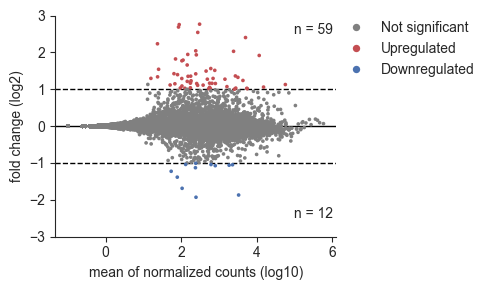

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))

sns.scatterplot(data=de_df, x="LogBaseMean", y="log2FoldChange", hue="Category",
                marker="o", s=7, linewidth=0, legend=True, ax=ax,
                palette={"Upregulated": "#C44E52", "Downregulated": "#4C72B0", "Not significant": "gray"})

# Set axes limits and labels
plt.ylim(-3, 3)
plt.ylabel("fold change (log2)")
plt.xlabel("mean of normalized counts (log10)")

# Add horizontal lines to indicate thresholds
plt.axhline(0, color="black", linestyle="-", linewidth=1, zorder=0)
plt.axhline(-1, color="black", linestyle="--", linewidth=1, zorder=0)
plt.axhline(1, color="black", linestyle="--", linewidth=1, zorder=0)

# Format legend
plt.legend(frameon=False, bbox_to_anchor=(1,1), loc="upper left", borderaxespad=0, markerscale=2)

# Add number of DEGs
nr_up = len(de_df[de_df["Category"] == "Upregulated"])
nr_down = len(de_df[de_df["Category"] == "Downregulated"])
plt.text(5, 2.5, f"n = {nr_up}")
plt.text(5, -2.5, f"n = {nr_down}")

sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure1d.svg", format="svg", bbox_inches="tight")
plt.show()

## Figure S1e: KEGG pathway enrichment of DEGs

In [12]:
enr = gp.enrichr(gene_list=de_df.loc[de_df["Category"] == "Upregulated", "GeneName"], 
                 gene_sets="KEGG_2026", organism="Human", outdir=None, cutoff=1)
display(enr.results)

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,KEGG_2026,PPAR SIGNALING PATHWAY,3/76,0.001471,0.057079,0,0,14.580235,95.087816,HMGCS1;ACSL1;FABP7
1,KEGG_2026,TERPENOID BACKBONE BIOSYNTHESIS,2/22,0.001903,0.057079,0,0,34.949123,218.939252,HMGCS1;MVD
2,KEGG_2026,CHOLESTEROL METABOLISM,2/51,0.009942,0.198838,0,0,14.244182,65.679906,PCSK9;LCAT
3,KEGG_2026,PHOSPHONATE AND PHOSPHINATE METABOLISM,1/6,0.017572,0.263580,0,0,68.744828,277.828629,PCYT2
4,KEGG_2026,GLYCEROPHOSPHOLIPID METABOLISM,2/102,0.036506,0.343421,0,0,6.961754,23.045326,PCYT2;LCAT
5,KEGG_2026,INSULIN RESISTANCE,2/107,0.039819,0.343421,0,0,6.628571,21.366602,MLXIPL;TRIB3
6,KEGG_2026,FATTY ACID BIOSYNTHESIS,1/18,0.051810,0.343421,0,0,20.206897,59.815709,ACSL1
7,KEGG_2026,PURINE METABOLISM,2/124,0.051882,0.343421,0,0,5.700029,16.865161,ENTPD1;GDA
8,KEGG_2026,STEROID BIOSYNTHESIS,1/20,0.057402,0.343421,0,0,18.078040,51.661282,TM7SF2
9,KEGG_2026,APELIN SIGNALING PATHWAY,2/138,0.062666,0.343421,0,0,5.109649,14.153367,RYR1;EGR1


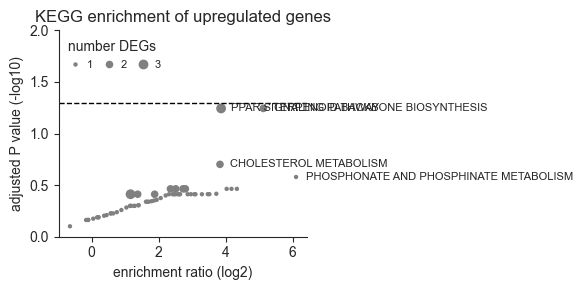

In [9]:
res = enr.results.copy()
res["-log10_adjp"] = -np.log10(res["Adjusted P-value"])
res["log2_enrichment"] = np.log2(res["Odds Ratio"])
res["GeneCount"] = res["Genes"].str.split(";").str.len()

fig, ax = plt.subplots(figsize=(6,3))

size_map = {1: 10, 2: 30, 3: 50, 4: 70, 5: 90}
sc = ax.scatter(res["log2_enrichment"], res["-log10_adjp"], c=["gray"], s=res["GeneCount"].map(size_map), linewidth=0)

handles, labels = sc.legend_elements("sizes")
for h in handles:
    h.set_markerfacecolor("gray")
ax.legend(handles, [1, 2, 3], title="number DEGs", frameon=False, bbox_to_anchor=(0.45,1), fontsize=8, ncols=3, columnspacing=0.5, handletextpad=0)

for _, row in res.nsmallest(4, "Adjusted P-value").iterrows():
    ax.text(row["log2_enrichment"] + 0.3, row["-log10_adjp"], row["Term"], fontsize=8, va="center")

ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
ax.set(xlabel="enrichment ratio (log2)", ylabel="adjusted P value (-log10)", title="KEGG enrichment of upregulated genes", ylim=(0, 2))
sns.despine()
plt.tight_layout()
plt.savefig(f"{output_dir}/SupplementalFigure1e.svg", format="svg", bbox_inches="tight")
plt.show()